In [1]:
from cats.cdataframe   import CDataFrame   # tool for extracting data from root files (made by your local developer, Mason Buchanan)

Welcome to JupyROOT 6.28/10


In [2]:
import matplotlib.pyplot as plt    # Matplotlib is the most common plotting package for Python

#The next line is a 'magic' command (indicated by the '%'). These tend to do useful meta things.
%matplotlib inline
#This one makes plots show up in your notebooks. (Note that you can't put comments after it on the same line!)

import pandas as pd                # Some additional data-handling tools
import numpy as np                 # "Numerical python". You need this to process data efficiently
import glob                        # Might be useful for getting files
import cdms
from rawio.IO import *             # Useful for reading binary files which contain raw pulses
import ROOT
import os,sys

CDMS = os.environ["CDMS"] # set in .bash_profile
stylesheet = os.path.join(CDMS,"scripts","stylesheets","rainbow.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup
import detectorLayout

In [3]:
DMCfiles = '/scratch/user/perry5334/samples/DMC_SNOLAB_HV/HV100mm_30eV_0V_tracks/DMCOutput/DMCOutput_51241116_000000.root'

In [4]:
EventNum = 2
channum = 6

# TESSim information is stored in 'G4SimDir/g4dmcTES' tree in the DMC file. Let's store the 'Trace' field.
g4dmcTES = CDataFrame('G4SimDir/g4dmcTES', [DMCfiles])
Trace = g4dmcTES.Filter(f'EventNum=={EventNum} & ChanNum=={channum} & DataType==0').AsNumpy(['Trace'])['Trace']
Trace = np.array([max(i) - i for i in Trace]) # flip traces right-side up

# Let's also store the 'ChanNum' and 'ChanName' fields..
ChanName = g4dmcTES.Filter(f'EventNum=={EventNum} & ChanNum=={channum} & DataType==0').AsNumpy(['ChanName'])['ChanName']
ChanNum  = g4dmcTES.Filter(f'EventNum=={EventNum} & ChanNum=={channum} & DataType==0').AsNumpy(['ChanNum'])['ChanNum']

# Let's also get the starting time of the TES pulse T0 and the width of the timebins BinWidths.
T0       = g4dmcTES.Filter(f'EventNum=={EventNum} & ChanNum=={channum} & DataType==0').AsNumpy(['T0'])['T0'][0]
BinWidth = g4dmcTES.Filter(f'EventNum=={EventNum} & ChanNum=={channum} & DataType==0').AsNumpy(['BinWidth'])['BinWidth'][0]
TimeBins = np.arange(T0, T0 + BinWidth * len(Trace[0]), BinWidth) * 1e-3 # ns -> us

In [5]:
EventNum = 2
channum = 6

# TESSim information is stored in 'G4SimDir/g4dmcTES' tree in the DMC file. Let's store the 'Trace' field.
g4dmcTES = CDataFrame('G4SimDir/g4dmcTES', [DMCfiles])
Profiles = g4dmcTES.Filter(f'EventNum=={EventNum} & DataType==4 & int(ChanNum)=={channum}').AsNumpy(['Trace'])['Trace']
Profile = np.sum(Profiles, axis=0)

In [79]:
mczip0 = CDataFrame('G4SimDir/mczip0', [DMCfiles])
zipdata_Q = mczip0.Filter('Charge != 0').Filter('EventNum == 2').AsNumpy(['X3', 'Y3', 'Z3', 'Yield', 'Weight', 'KE', 'Time3', 'Charge', 'Track'])
zipdata_P = mczip0.Filter('Charge == 0').Filter('EventNum == 2').AsNumpy(['X3', 'Y3', 'Z3', 'Yield', 'Weight', 'KE', 'Time3', 'Charge', 'Track', 'ChanNum'])

Text(0, 1, 'Amplitude [$\\mathrm{\\mu A}$]')

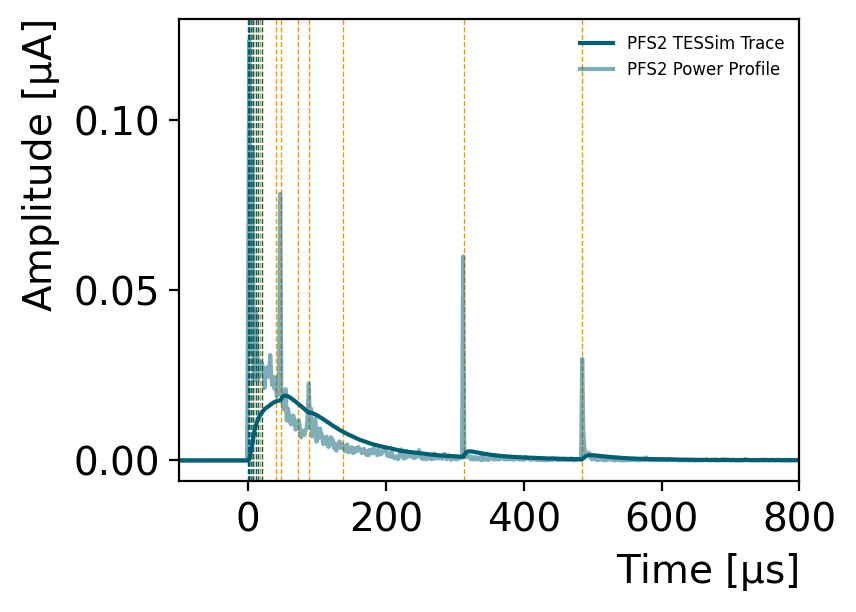

In [7]:
plt.figure(figsize=(4,3), dpi=200)
    
plt.plot(TimeBins, Trace[0], color = 'C0', label = f'{ChanName[0]} TESSim Trace')
plt.plot(TimeBins, Profile*1e12 / sum(Profile*1e12) * sum(Trace[0]), color = 'C0', label = f'{ChanName[0]} Power Profile', alpha = 0.5)

t0 = min(zipdata_P['Time3'])*1e-3
for i, time in enumerate(zipdata_Q['Time3']*1e-3):
    plt.axvline(time-t0, 0, 1, color = ['C0', 'C4'][zipdata_Q['Charge'][i] == -1], zorder = -1, ls = '--', lw = 0.5)
    
plt.xlim(-100, 800)
#plt.xlim(270, 300)
plt.legend(fontsize = 6)
plt.xlabel(r'Time [$\mathrm{\mu s}$]')
plt.ylabel(r'Amplitude [$\mathrm{\mu A}$]')

In [26]:
HitCounter = CDataFrame('G4SimDir/mcHitCounter', [DMCfiles])
stepdata_Q = HitCounter.Filter('Charge != 0').Filter('EventNum == 2').AsNumpy(['Charge', 'Track', 'Time1', 'KE', 'Time3', 'Weight', 'Process'])
stepdata_P = HitCounter.Filter('Charge == 0').Filter('EventNum == 2').AsNumpy(['Charge', 'Track', 'Time1', 'KE', 'Time3', 'Weight', 'Process', 'Yield'])

In [76]:
TrackCut = np.array([i in zipdata_P['Track'] for i in stepdata_P['Track']])

In [77]:
Track = np.array([j for j in stepdata_P['Track'][TrackCut]])
Energy = np.array([j for j in stepdata_P['Yield'][TrackCut]*stepdata_P['Weight'][TrackCut]])
Process = np.array([j for j in stepdata_P['Process'][TrackCut]])

In [80]:
t0 = min(zipdata_P['Time3'])*1e-3
bins = len(np.arange(0, 600, 1.6))
absorbed = {'G4CMPChargeBoundary': np.zeros(bins),
            'G4CMPChargeRecombine': np.zeros(bins),
            'G4CMPLukeScattering': np.zeros(bins),
            'G4CMPPhononBoundary': np.zeros(bins),
            'phononDownconversion': np.zeros(bins)}

for i, t in enumerate(np.arange(0, 600, 1.6)):
    
    TimeCut = (zipdata_P['Time3']*1e-3 - t0 > t) & (zipdata_P['Time3']*1e-3 - t0 < t + 1.6)
    absCut = zipdata_P['ChanNum'] == 6
    Tracks = zipdata_P['Track'][TimeCut & absCut]

    for Trk in Tracks:
        TrackCut = Track == Trk
        absorbed[Process[TrackCut][0]][i] += Energy[TrackCut][0]

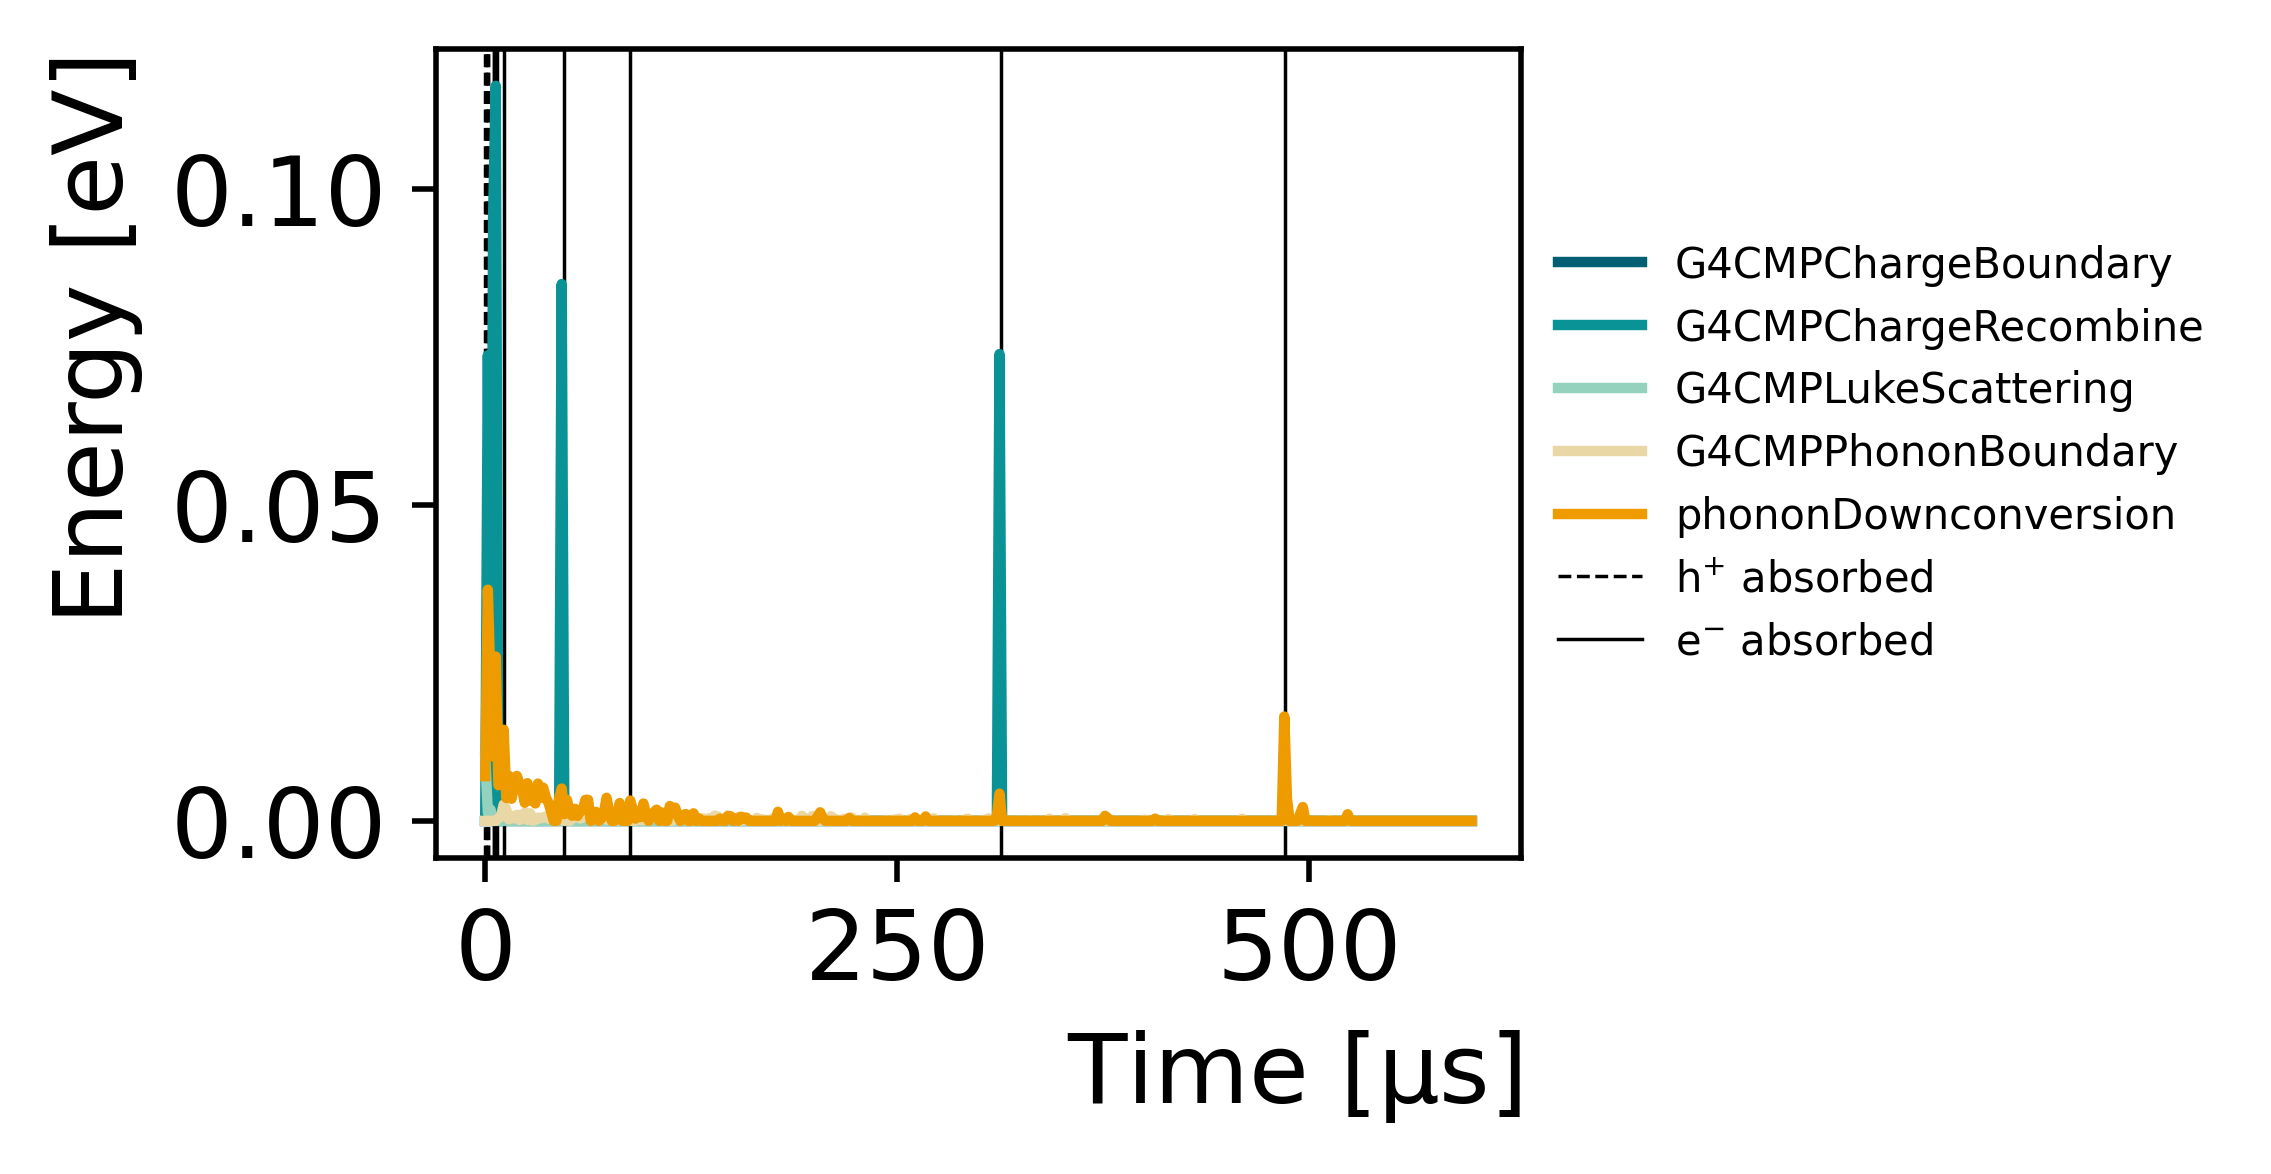

In [85]:
fig = plt.figure(figsize=(5*0.7,3*0.7), dpi = 500)
ax = plt.subplot(111)

for j, key in enumerate(list(absorbed.keys())):
    ax.plot(np.arange(0, 600, 1.6), absorbed[key], color = f'C{j}', label = key)

t0 = min(zipdata_P['Time3'])*1e-3
elabel = False
hlabel = False
Zcut = zipdata_Q['Z3'] < 0
Rcut = np.sqrt(zipdata_Q['X3']**2 + zipdata_Q['Y3']**2)*1e3 < 19.592
for i, time in enumerate(zipdata_Q['Time3'][Zcut & Rcut]*1e-3):
    if (zipdata_Q['Charge'][Zcut & Rcut][i] == -1) & (elabel==False):
        ax.axvline(time-t0, 0, 1, zorder = -1, ls = ['--', '-'][zipdata_Q['Charge'][Zcut & Rcut][i] == -1], lw = 0.5, color = 'black', label = r'e$^{-}$ absorbed')
        elabel=True
    if (zipdata_Q['Charge'][Zcut & Rcut][i] == 1) & (hlabel==False):
        ax.axvline(time-t0, 0, 1, zorder = -1, ls = ['--', '-'][zipdata_Q['Charge'][Zcut & Rcut][i] == -1], lw = 0.5, color = 'black', label = r'h$^{+}$ absorbed')
        hlabel=True
    else:
        ax.axvline(time-t0, 0, 1, zorder = -1, ls = ['--', '-'][zipdata_Q['Charge'][Zcut & Rcut][i] == -1], lw = 0.5, color = 'black')

ax.set_xlabel(r'Time [$\mathrm{\mu s}$]')
ax.set_ylabel(r'Energy [eV]')

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=6)

Text(0, 1, 'Amplitude [$\\mathrm{\\mu A}$]')

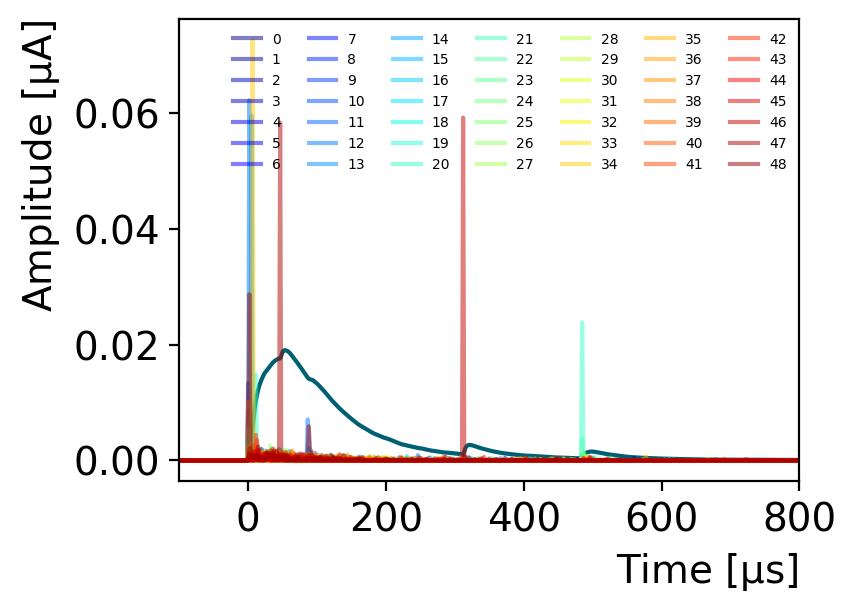

In [8]:
cmap = plt.get_cmap('jet')
ptcolor = [cmap(i) for i in np.linspace(0, 1, 50)]

plt.figure(figsize=(4,3), dpi=200)
    
plt.plot(TimeBins, Trace[0], color = 'C0')

for tes, P in enumerate(Profiles):
    plt.plot(TimeBins, P*1e12 / sum(Profile*1e12) * sum(Trace[0]), alpha = 0.5, label = f'{tes}', color = ptcolor[tes])
    
plt.xlim(-100, 800)
plt.legend(ncol=7, fontsize = 5, loc = 'upper right')
plt.xlabel(r'Time [$\mathrm{\mu s}$]')
plt.ylabel(r'Amplitude [$\mathrm{\mu A}$]')

In [9]:
g4dmcHits = CDataFrame('G4SimDir/g4dmcHits', DMCfiles)
hitsData = g4dmcHits.Filter('EventNum == 2').AsNumpy(['X', 'Y', 'Z', 'Time'])

Text(0, 1, 'Y position [mm]')

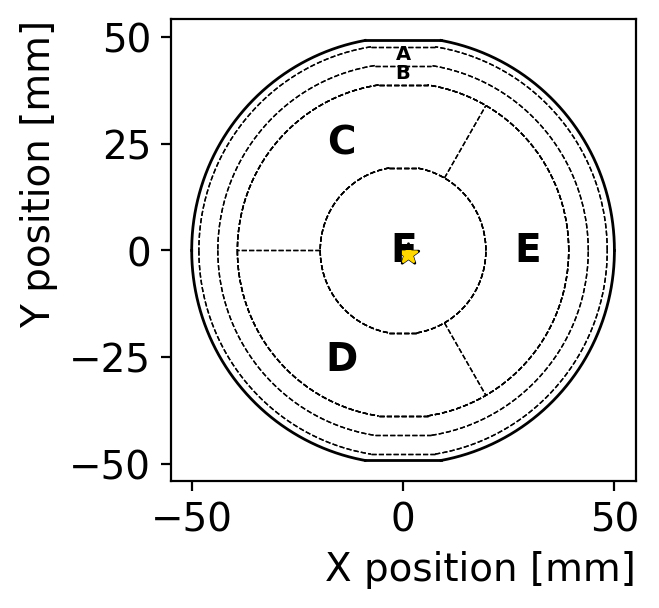

In [10]:
plt.figure(figsize=(3,3), dpi=200)
plt.scatter(hitsData['X']*1e3, hitsData['Y']*1e3, marker = '*', color = 'black', s = 60)
plt.scatter(hitsData['X']*1e3, hitsData['Y']*1e3, marker = '*', color = 'gold', s = 40)
detectorLayout.drawDetOutline(DMCfiles, color='black', lw = 1, ls = '-')
detectorLayout.drawChanOutline(DMCfiles, color='black', side=1, chantype=1, labels=0, lw = 0.5, ls = '--')

plt.text(0, 0, r'$\mathbf{F}$', ha='center', va='center')
plt.text(19.592 + (39.192 - 19.592)/2, 0, r'$\mathbf{E}$', ha='center', va='center')
plt.text((19.592 + (39.192 - 19.592)/2) * np.cos(4 * np.pi / 3), (19.592 + (39.192 - 19.592)/2) * np.sin(4 * np.pi / 3), r'$\mathbf{D}$', ha='center', va='center')
plt.text((19.592 + (39.192 - 19.592)/2) * np.cos(2 * np.pi / 3), (19.592 + (39.192 - 19.592)/2) * np.sin(2 * np.pi / 3), r'$\mathbf{C}$', ha='center', va='center')
plt.text(0, 39.192 + (43.818 - 39.192)/2, r'$\mathbf{B}$', ha='center', va='center', fontsize = 7)
plt.text(0, 43.818 + (48.3 - 43.818)/2, r'$\mathbf{A}$', ha='center', va='center', fontsize = 7)

plt.xlabel('X position [mm]')
plt.ylabel('Y position [mm]')

In [36]:
g4dmcHits = CDataFrame('G4SimDir/mcHitCounter', [DMCfiles])
zipdata = g4dmcHits.Filter('Charge != 0').Filter('EventNum == 2').AsNumpy(['X3', 'Y3', 'Z3', 'X1', 'Y1', 'Z1', 'Charge', 'Track', 'Time1', 'Time3'])

Text(0, 1, 'Z position [mm]')

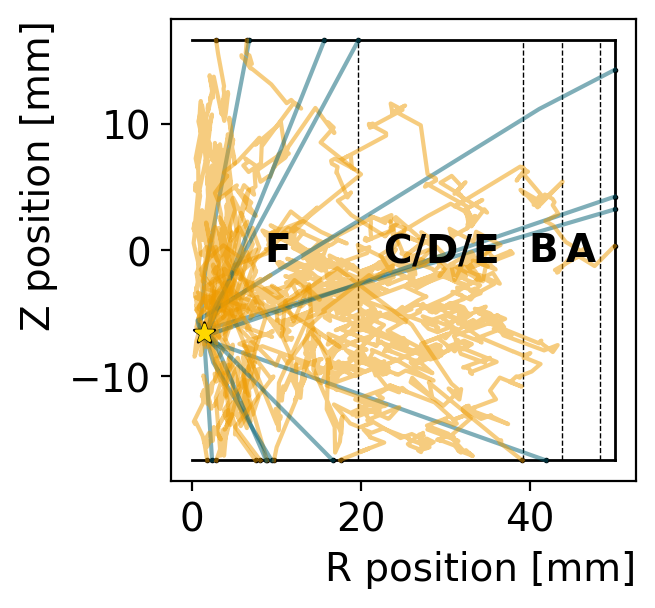

In [37]:
plt.figure(figsize=(3,3), dpi=200)
plt.scatter(np.sqrt((hitsData['X']*1e3)**2 + (hitsData['Y']*1e3)**2), hitsData['Z']*1e3, marker = '*', color = 'black', zorder = 20, s = 60)
plt.scatter(np.sqrt((hitsData['X']*1e3)**2 + (hitsData['Y']*1e3)**2), hitsData['Z']*1e3, marker = '*', color = 'gold', zorder = 20, s = 40)

plt.plot([0, 50], [-33.33/2, -33.33/2], lw = 1, color = 'black')
plt.plot([0, 50], [33.33/2, 33.33/2], lw = 1, color = 'black')
plt.plot([50, 50], [-33.33/2, 33.33/2], lw = 1, color = 'black')

plt.plot([19.592, 19.592], [-33.33/2, 33.33/2], lw = 0.5, ls = '--', color = 'black')
plt.plot([39.192, 39.192], [-33.33/2, 33.33/2], lw = 0.5, ls = '--', color = 'black')
plt.plot([43.818, 43.818], [-33.33/2, 33.33/2], lw = 0.5, ls = '--', color = 'black')
plt.plot([48.3, 48.3], [-33.33/2, 33.33/2], lw = 0.5, ls = '--', color = 'black')

plt.text(10, 0, r'$\mathbf{F}$', ha='center', va='center')
plt.text(19.592 + (39.192 - 19.592)/2, 0, r'$\mathbf{C/D/E}$', ha='center', va='center')
plt.text(39.192 + (43.818 - 39.192)/2, 0, r'$\mathbf{B}$', ha='center', va='center')
plt.text(43.818 + (48.3 - 43.818)/2, 0, r'$\mathbf{A}$', ha='center', va='center')

for Track in np.unique(zipdata['Track']):
    TrackCut = zipdata['Track'] == Track
    Time = zipdata['Time3'][TrackCut]
    Charge = zipdata['Charge'][TrackCut][0]
    X = zipdata['X3'][TrackCut]*1e3
    Y = zipdata['Y3'][TrackCut]*1e3
    Z = zipdata['Z3'][TrackCut]*1e3
    R = np.sqrt(X**2 + Y**2)

    Timesort, Rsort, Zsort = zip(*sorted(zip(Time, R, Z)))

    plt.plot(Rsort, Zsort, color = ['C0', 'C4'][Charge == -1], alpha = 0.5)
    plt.scatter([Rsort[-1]], [Zsort[-1]], color = 'black', s=1)
    

plt.xlabel('R position [mm]')
plt.ylabel('Z position [mm]')

Text(0, 1, 'Z position [mm]')

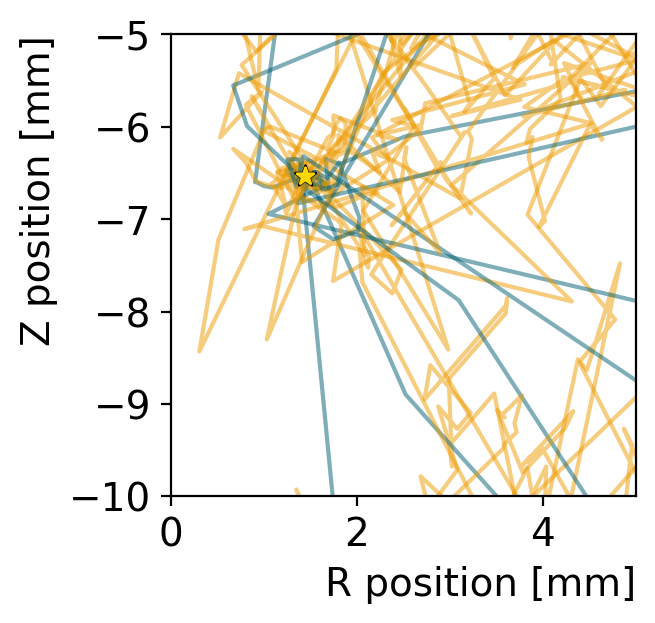

In [16]:
plt.figure(figsize=(3,3), dpi=200)
plt.scatter(np.sqrt((hitsData['X']*1e3)**2 + (hitsData['Y']*1e3)**2), hitsData['Z']*1e3, marker = '*', color = 'black', zorder = 20, s = 60)
plt.scatter(np.sqrt((hitsData['X']*1e3)**2 + (hitsData['Y']*1e3)**2), hitsData['Z']*1e3, marker = '*', color = 'gold', zorder = 20, s = 40)

plt.plot([0, 50], [-33.33/2, -33.33/2], lw = 1, color = 'black')
plt.plot([0, 50], [33.33/2, 33.33/2], lw = 1, color = 'black')
plt.plot([50, 50], [-33.33/2, 33.33/2], lw = 1, color = 'black')

plt.plot([19.592, 19.592], [-33.33/2, 33.33/2], lw = 0.5, ls = '--', color = 'black')
plt.plot([39.192, 39.192], [-33.33/2, 33.33/2], lw = 0.5, ls = '--', color = 'black')
plt.plot([43.818, 43.818], [-33.33/2, 33.33/2], lw = 0.5, ls = '--', color = 'black')
plt.plot([48.3, 48.3], [-33.33/2, 33.33/2], lw = 0.5, ls = '--', color = 'black')

for Track in np.unique(zipdata['Track']):
    TrackCut = zipdata['Track'] == Track
    Time = zipdata['Time3'][TrackCut]
    Charge = zipdata['Charge'][TrackCut][0]
    X = zipdata['X3'][TrackCut]*1e3
    Y = zipdata['Y3'][TrackCut]*1e3
    Z = zipdata['Z3'][TrackCut]*1e3
    R = np.sqrt(X**2 + Y**2)

    Timesort, Rsort, Zsort = zip(*sorted(zip(Time, R, Z)))

    plt.plot(Rsort, Zsort, color = ['C0', 'C4'][Charge == -1], alpha = 0.5)

plt.xlim(0, 5)
plt.ylim(-10, -5)
    

plt.xlabel('R position [mm]')
plt.ylabel('Z position [mm]')

In [34]:
g4dmcHits = CDataFrame('G4SimDir/mczip0', [DMCfiles])
zipdata = g4dmcHits.Filter('Charge != 0').Filter('EventNum == 2').AsNumpy(['X3', 'Y3', 'Z3', 'Yield', 'Weight', 'KE', 'Time3', 'Charge'])

Text(0, 1, 'Y position [mm]')

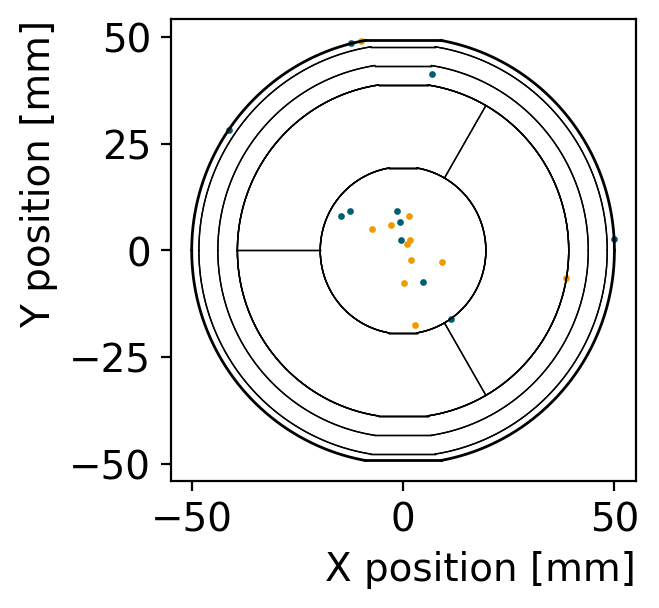

In [35]:
plt.figure(figsize=(3,3), dpi=200)

for i in range(len(zipdata['X3'])):
    plt.scatter(zipdata['X3'][i]*1e3, zipdata['Y3'][i]*1e3, s = 2, color = ['C0', 'C4'][zipdata['Charge'][i] == -1])

detectorLayout.drawDetOutline(DMCfiles, color='black', lw = 1, ls = '-')
detectorLayout.drawChanOutline(DMCfiles, color='black', side=1, chantype=1, labels=0, lw = 0.5, ls = '-')

plt.xlabel('X position [mm]')
plt.ylabel('Y position [mm]')
#plt.xlim(0, 10)
#plt.ylim(-10, 0)

In [ ]:
g4dmcHits = CDataFrame('G4SimDir/mczip0', [DMCfiles])
zipdata = g4dmcHits.Filter('Charge == 0').Filter('EventNum == 2').AsNumpy(['X3', 'Y3', 'Z3', 'Yield', 'Weight', 'KE', 'Time3'])

Text(0, 1, 'Y position [mm]')

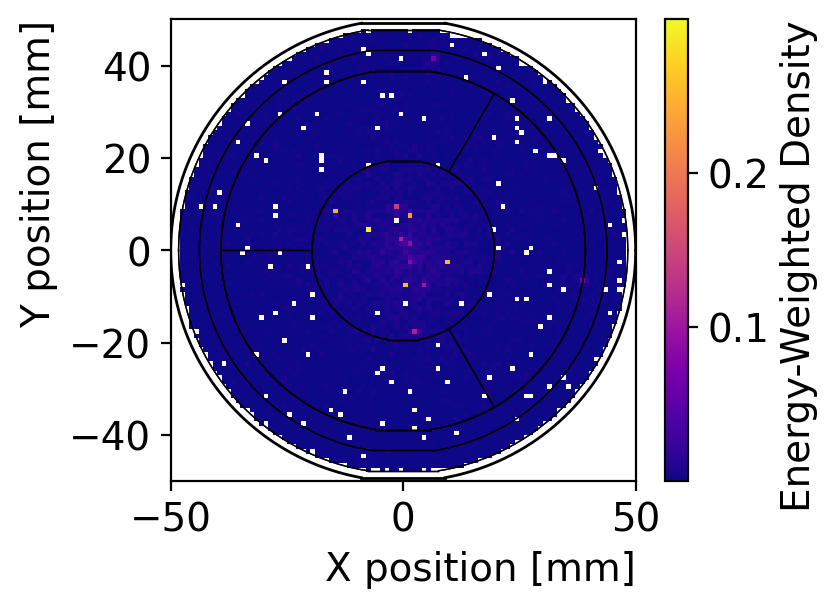

In [18]:
plt.figure(figsize=(3.75,3), dpi=200)
t0 = min(zipdata['Time3'])
startwindow = t0 + 57e3
endwindow = t0 + 63e3

cuts = (zipdata['Z3'] < 0)

# Create 2D histogram
hist, xedges, yedges = np.histogram2d(zipdata['X3'][cuts]*1e3, zipdata['Y3'][cuts]*1e3, 
                                      bins=[np.linspace(-50, 50, 101), np.linspace(-50, 50, 101)], 
                                      weights = (zipdata['Yield']*zipdata['Weight'])[cuts])

# Mask bins with zero counts
hist = np.ma.masked_where(hist == 0, hist)

# Plot the 2D histogram with masked bins
plt.pcolormesh(xedges, yedges, hist.T, cmap='plasma')

# Set the color of masked bins to white
plt.gca().patch.set_color('white')

# Add color bar to show the density scale
plt.colorbar(label='Energy-Weighted Density')

detectorLayout.drawDetOutline(DMCfiles, color='black', lw = 1, ls = '-')
detectorLayout.drawChanOutline(DMCfiles, color='black', side=1, chantype=1, labels=0, lw = 0.5, ls = '-')

plt.xlabel('X position [mm]')
plt.ylabel('Y position [mm]')
#plt.xlim(0, 10)
#plt.ylim(-10, 0)

In [ ]:
plt.figure(figsize=(3.75,3), dpi=200)
t0 = min(zipdata['Time3'])
startwindow = t0 + 281e3
endwindow = t0 + 287e3

cuts = (zipdata['Z3'] > 0) & (zipdata['Time3'] >= startwindow) & (zipdata['Time3'] <= endwindow)

# Create 2D histogram
hist, xedges, yedges = np.histogram2d(zipdata['X3'][cuts]*1e3, zipdata['Y3'][cuts]*1e3, 
                                      bins=[np.linspace(-50, 50, 101), np.linspace(-50, 50, 101)], 
                                      weights = (zipdata['Yield']*zipdata['Weight'])[cuts])

# Mask bins with zero counts
hist = np.ma.masked_where(hist == 0, hist)

# Plot the 2D histogram with masked bins
plt.pcolormesh(xedges, yedges, hist.T, cmap='plasma')

# Set the color of masked bins to white
plt.gca().patch.set_color('white')

# Add color bar to show the density scale
plt.colorbar(label='Energy-Weighted Density')

detectorLayout.drawDetOutline(DMCfiles, color='black', lw = 1, ls = '-')
detectorLayout.drawChanOutline(DMCfiles, color='black', side=1, chantype=1, labels=0, lw = 0.5, ls = '-')

plt.xlabel('X position [mm]')
plt.ylabel('Y position [mm]')
#plt.xlim(0, 10)
#plt.ylim(-10, 0)